# Visualização de Amostras do Dataset

Este notebook seleciona algumas imagens aleatórias do dataset, plota seus bounding boxes e exibe as labels para conferência visual.

In [2]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

In [3]:
# Selecione o split que deseja visualizar
split = 'train'  # Opções: 'train', 'val', 'test'

# Parâmetros
base_dir = f'../dataset/{split}'
images_dir = os.path.join(base_dir, 'images')
labels_dir = os.path.join(base_dir, 'labels')
classes = ['copo', 'fone']
num_samples = 5  # Quantidade de imagens para visualizar

print(f"Visualizando amostras do split: {split}")
print(f"Diretório de imagens: {images_dir}")

# Verifica se os diretórios existem
if not os.path.exists(images_dir) or not os.path.exists(labels_dir):
    print(f"ERRO: Diretórios não encontrados para o split {split}")
else:
    # Conta o número de imagens disponíveis
    image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    print(f"Total de imagens disponíveis: {len(image_files)}")
    
    # Conta imagens por classe
    imagens_por_classe = {0: 0, 1: 0}
    imagens_multi_classe = 0
    
    for img_name in image_files:
        label_path = os.path.join(labels_dir, os.path.splitext(img_name)[0] + '.txt')
        if os.path.exists(label_path):
            classes_na_imagem = set()
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 1:
                        try:
                            cls_id = int(float(parts[0]))
                            classes_na_imagem.add(cls_id)
                        except:
                            pass
            
            if len(classes_na_imagem) > 1:
                imagens_multi_classe += 1
            elif len(classes_na_imagem) == 1:
                cls_id = list(classes_na_imagem)[0]
                if cls_id in imagens_por_classe:
                    imagens_por_classe[cls_id] += 1
    
    print(f"Imagens de {classes[0]}: {imagens_por_classe[0]}")
    print(f"Imagens de {classes[1]}: {imagens_por_classe[1]}")
    if imagens_multi_classe > 0:
        print(f"Imagens com múltiplas classes: {imagens_multi_classe}")
    
    # Seleciona imagens aleatórias
    amostras = random.sample(image_files, min(num_samples, len(image_files)))

Visualizando amostras do split: train
Diretório de imagens: ../dataset/train\images
Total de imagens disponíveis: 80
Imagens de copo: 40
Imagens de fone: 40


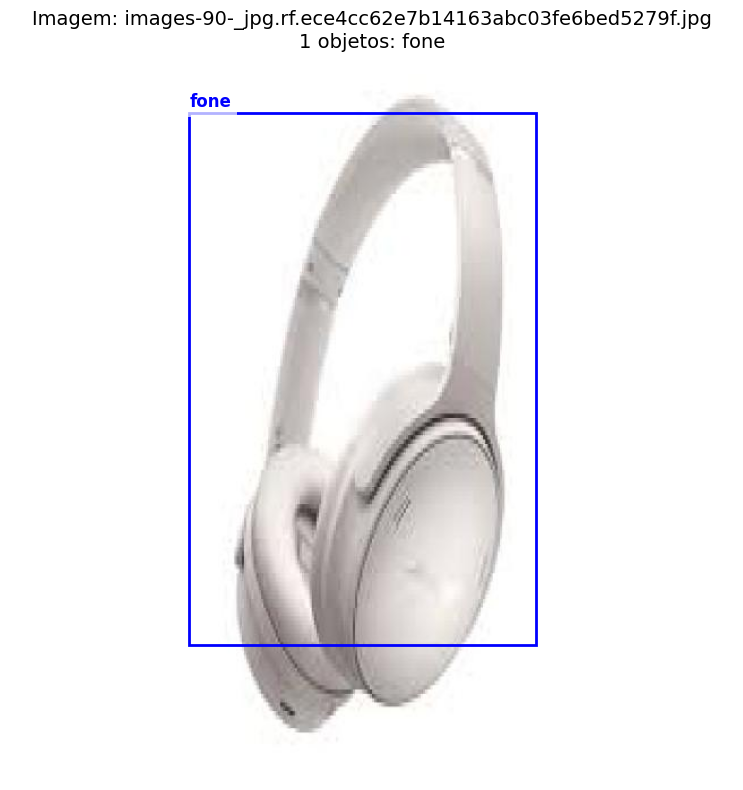

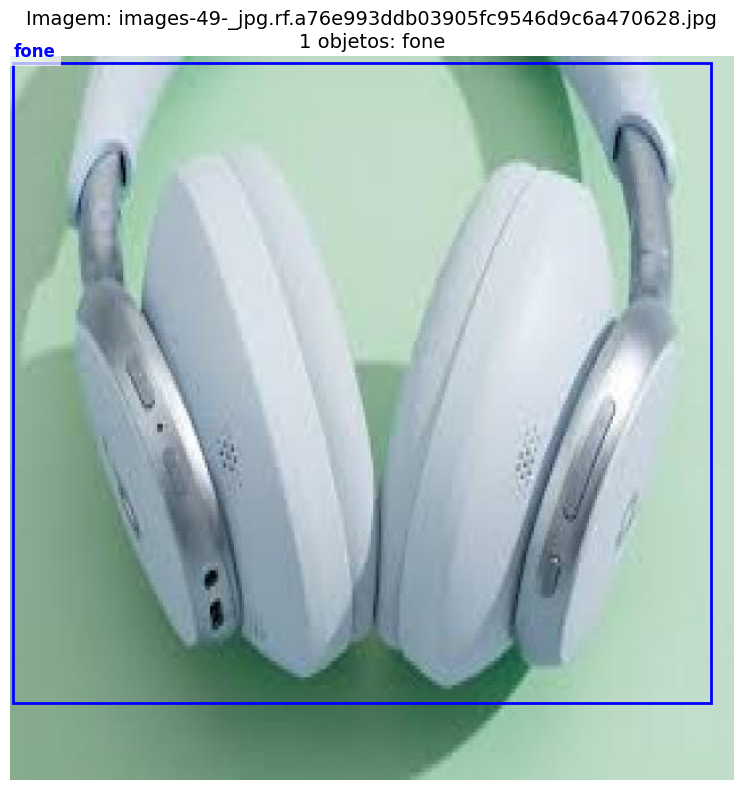

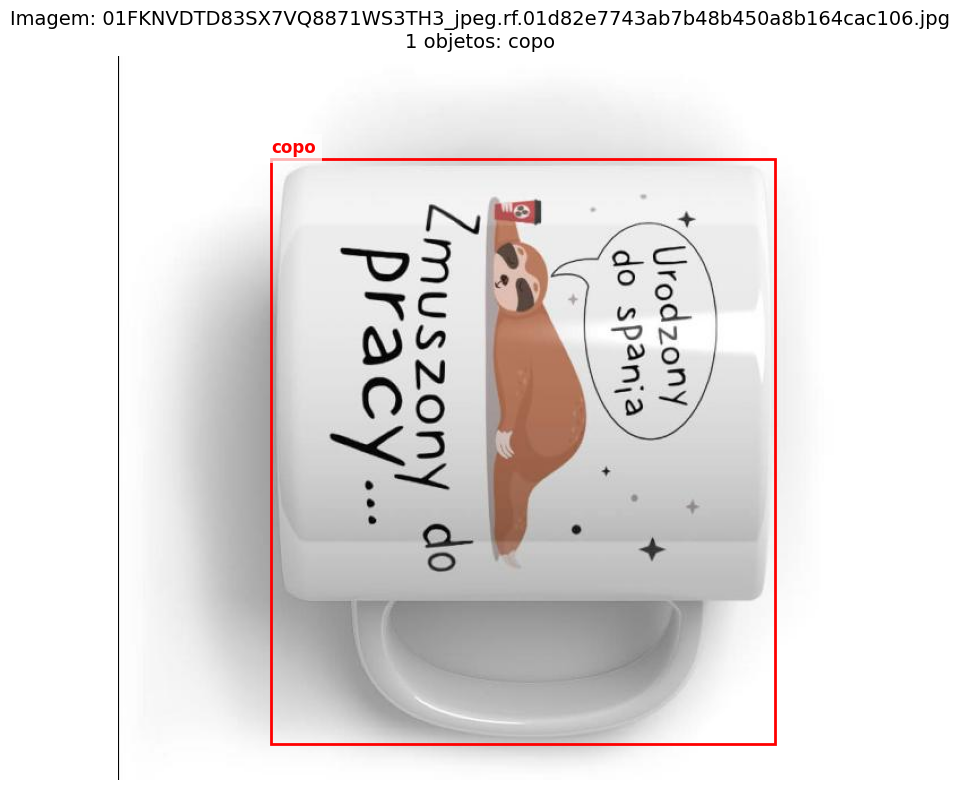

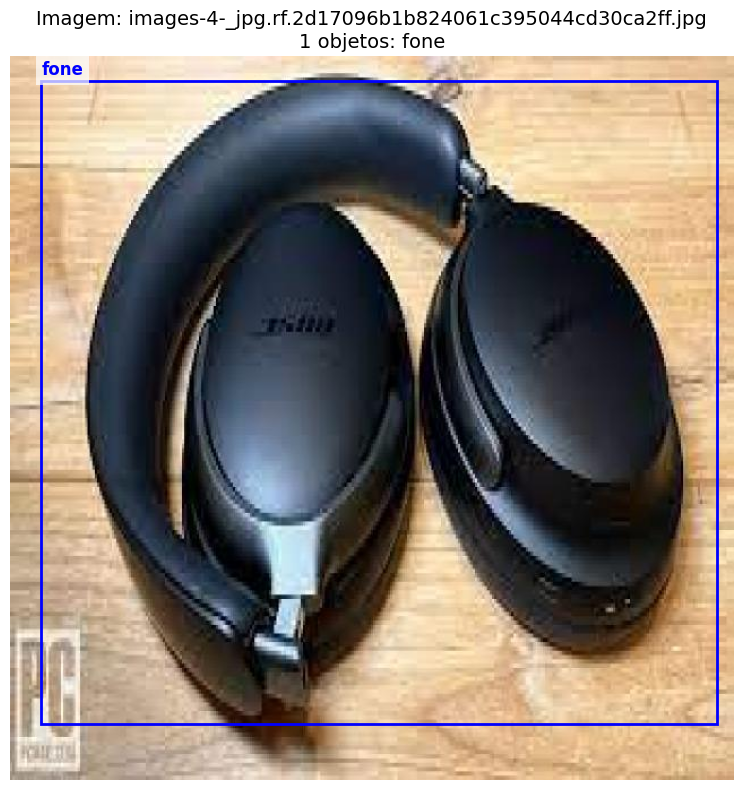

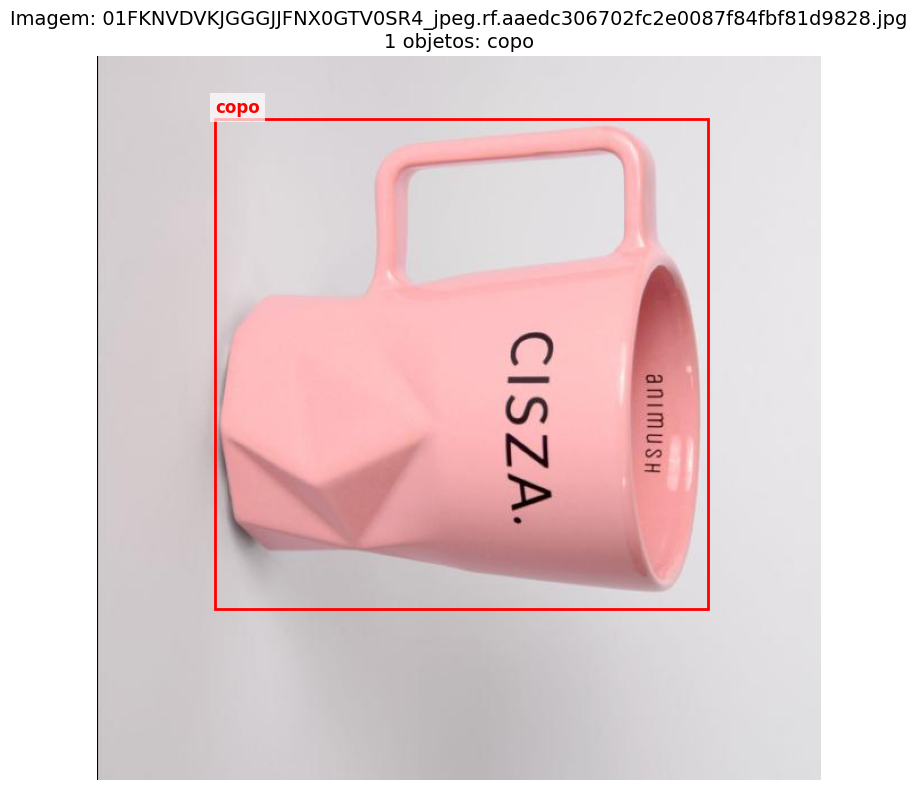

In [4]:
# Visualiza as amostras selecionadas
for img_name in amostras:
    img_path = os.path.join(images_dir, img_name)
    label_path = os.path.join(labels_dir, os.path.splitext(img_name)[0] + '.txt')
    
    # Abre imagem
    img = Image.open(img_path)
    w, h = img.size
    
    # Lê labels
    boxes = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id, xc, yc, bw, bh = map(float, parts)
                    # Converte YOLO para coordenadas de canto
                    x1 = (xc - bw/2) * w
                    y1 = (yc - bh/2) * h
                    x2 = (xc + bw/2) * w
                    y2 = (yc + bh/2) * h
                    boxes.append((cls_id, x1, y1, x2-x1, y2-y1))
    
    # Plota
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)
    
    # Adiciona bounding boxes e labels
    for cls_id, x, y, bw, bh in boxes:
        color = 'red' if int(cls_id) == 0 else 'blue'
        rect = patches.Rectangle((x, y), bw, bh, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y-5, classes[int(cls_id)], color=color, fontsize=12, weight='bold', 
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    
    # Exibe nome do arquivo e informações
    num_boxes = len(boxes)
    box_info = f"{num_boxes} objetos: " + ", ".join([classes[int(b[0])] for b in boxes]) if boxes else "Sem objetos"
    ax.set_title(f'Imagem: {img_name}\n{box_info}', fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

## Visualizar outro split (Val)

Visualizando amostras do split: val
Diretório de imagens: ../dataset/val\images
Total de imagens disponíveis: 10
Imagens de copo: 5
Imagens de fone: 5


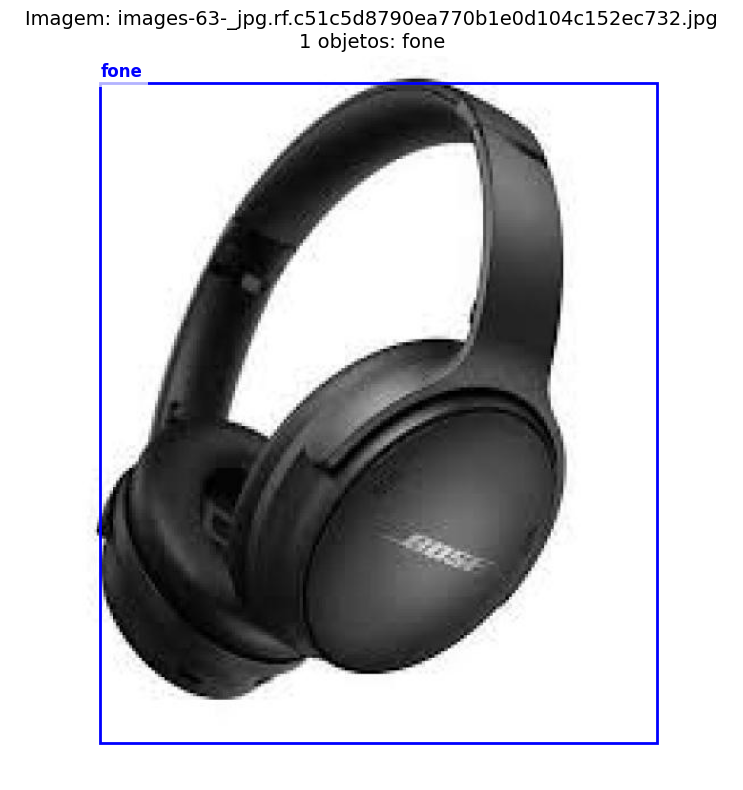

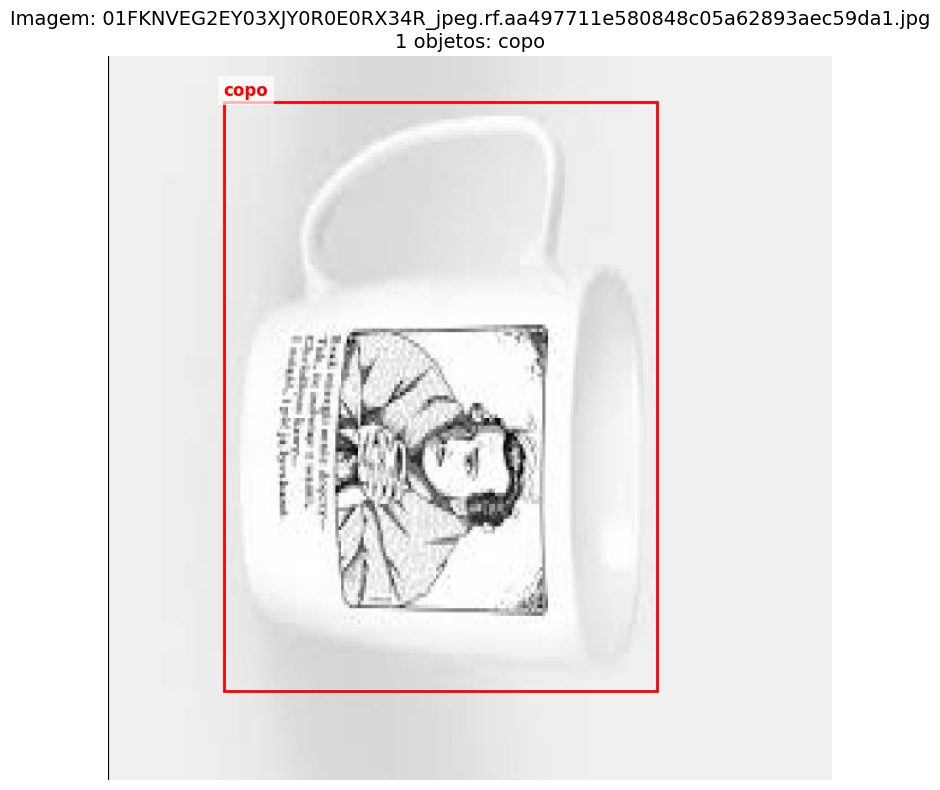

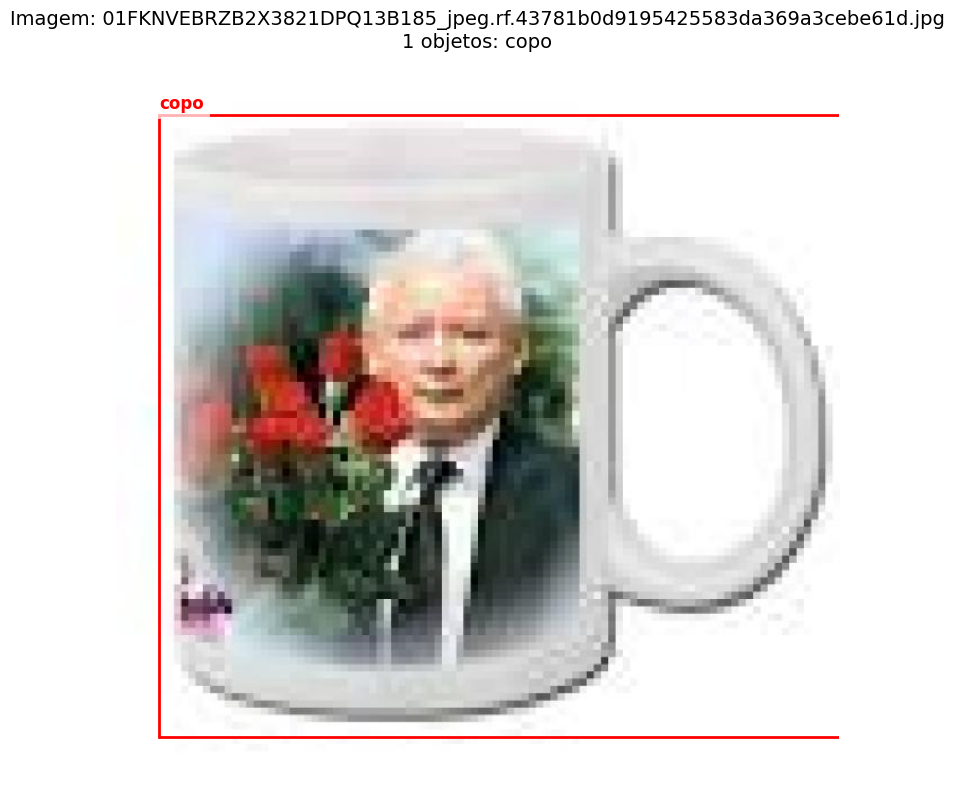

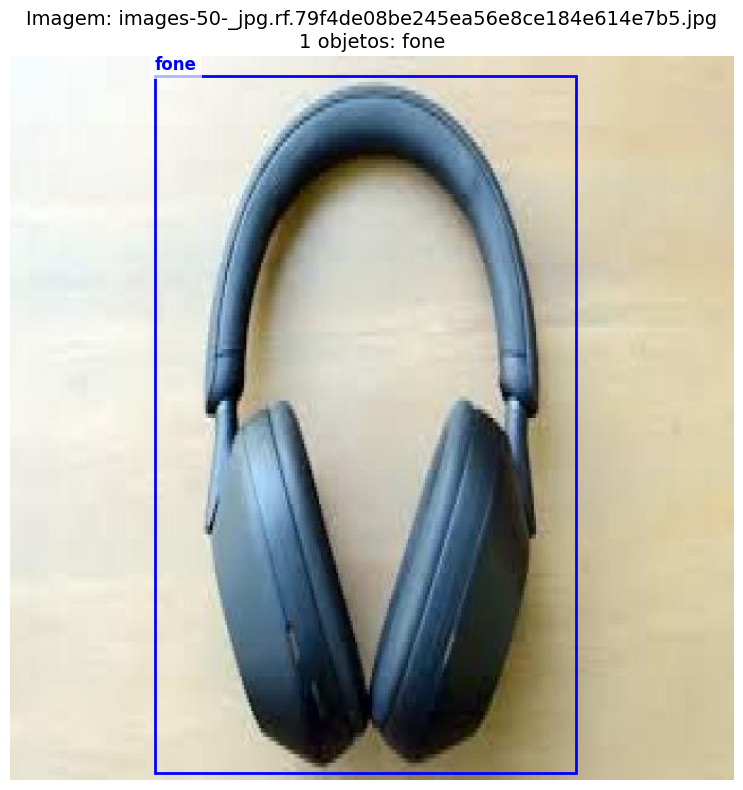

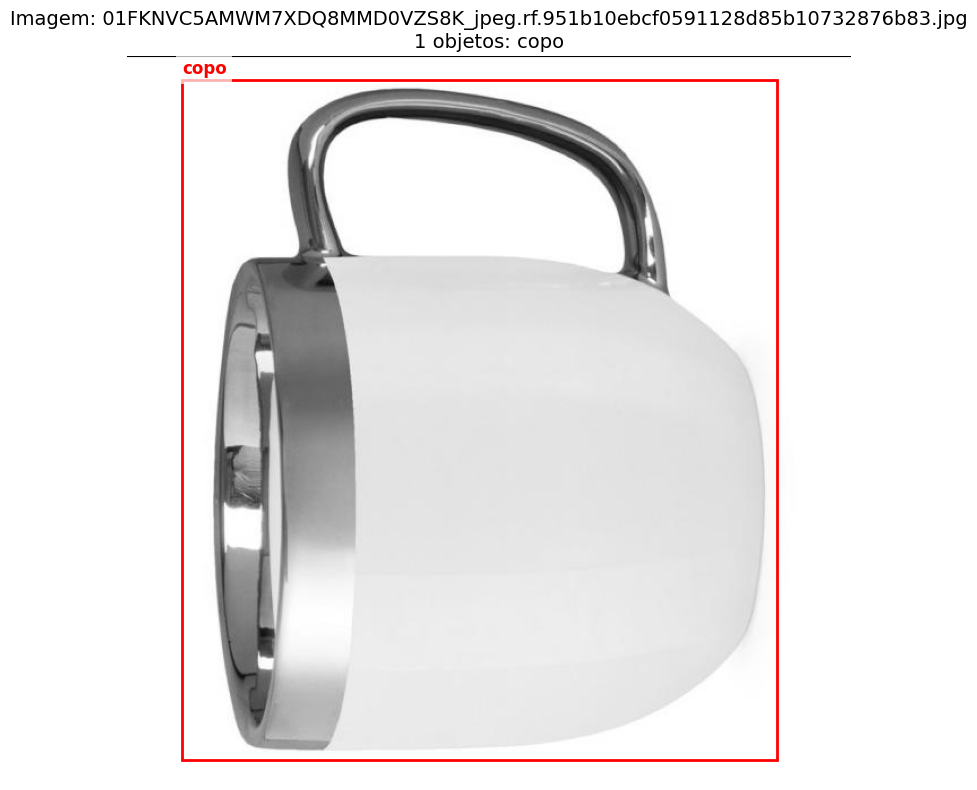

In [5]:
# Muda para o split de validação
split = 'val'  # Validação

# Parâmetros
base_dir = f'../dataset/{split}'
images_dir = os.path.join(base_dir, 'images')
labels_dir = os.path.join(base_dir, 'labels')

print(f"Visualizando amostras do split: {split}")
print(f"Diretório de imagens: {images_dir}")

# Verifica se os diretórios existem
if not os.path.exists(images_dir) or not os.path.exists(labels_dir):
    print(f"ERRO: Diretórios não encontrados para o split {split}")
else:
    # Conta o número de imagens disponíveis
    image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    print(f"Total de imagens disponíveis: {len(image_files)}")
    
    # Conta imagens por classe
    imagens_por_classe = {0: 0, 1: 0}
    imagens_multi_classe = 0
    
    for img_name in image_files:
        label_path = os.path.join(labels_dir, os.path.splitext(img_name)[0] + '.txt')
        if os.path.exists(label_path):
            classes_na_imagem = set()
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 1:
                        try:
                            cls_id = int(float(parts[0]))
                            classes_na_imagem.add(cls_id)
                        except:
                            pass
            
            if len(classes_na_imagem) > 1:
                imagens_multi_classe += 1
            elif len(classes_na_imagem) == 1:
                cls_id = list(classes_na_imagem)[0]
                if cls_id in imagens_por_classe:
                    imagens_por_classe[cls_id] += 1
    
    print(f"Imagens de {classes[0]}: {imagens_por_classe[0]}")
    print(f"Imagens de {classes[1]}: {imagens_por_classe[1]}")
    if imagens_multi_classe > 0:
        print(f"Imagens com múltiplas classes: {imagens_multi_classe}")
    
    # Seleciona imagens aleatórias
    amostras = random.sample(image_files, min(num_samples, len(image_files)))
    
    # Visualiza as amostras selecionadas
    for img_name in amostras:
        img_path = os.path.join(images_dir, img_name)
        label_path = os.path.join(labels_dir, os.path.splitext(img_name)[0] + '.txt')
        
        # Abre imagem
        img = Image.open(img_path)
        w, h = img.size
        
        # Lê labels
        boxes = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls_id, xc, yc, bw, bh = map(float, parts)
                        # Converte YOLO para coordenadas de canto
                        x1 = (xc - bw/2) * w
                        y1 = (yc - bh/2) * h
                        x2 = (xc + bw/2) * w
                        y2 = (yc + bh/2) * h
                        boxes.append((cls_id, x1, y1, x2-x1, y2-y1))
        
        # Plota
        fig, ax = plt.subplots(1, figsize=(10, 8))
        ax.imshow(img)
        
        # Adiciona bounding boxes e labels
        for cls_id, x, y, bw, bh in boxes:
            color = 'red' if int(cls_id) == 0 else 'blue'
            rect = patches.Rectangle((x, y), bw, bh, linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x, y-5, classes[int(cls_id)], color=color, fontsize=12, weight='bold', 
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        
        # Exibe nome do arquivo e informações
        num_boxes = len(boxes)
        box_info = f"{num_boxes} objetos: " + ", ".join([classes[int(b[0])] for b in boxes]) if boxes else "Sem objetos"
        ax.set_title(f'Imagem: {img_name}\n{box_info}', fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

## Visualizar outro split (Test)

Visualizando amostras do split: test
Diretório de imagens: ../dataset/test\images
Total de imagens disponíveis: 10
Imagens de copo: 5
Imagens de fone: 5


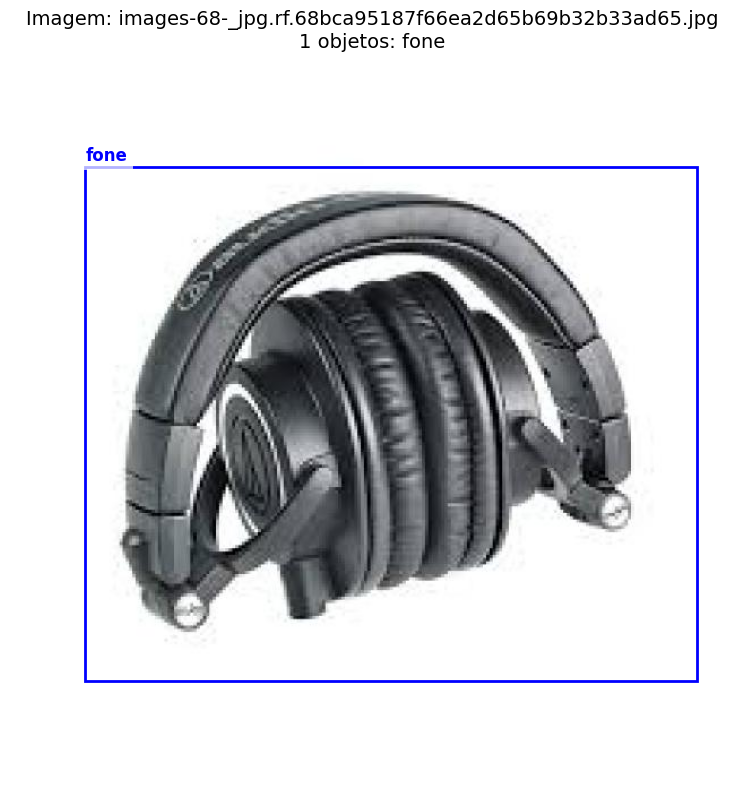

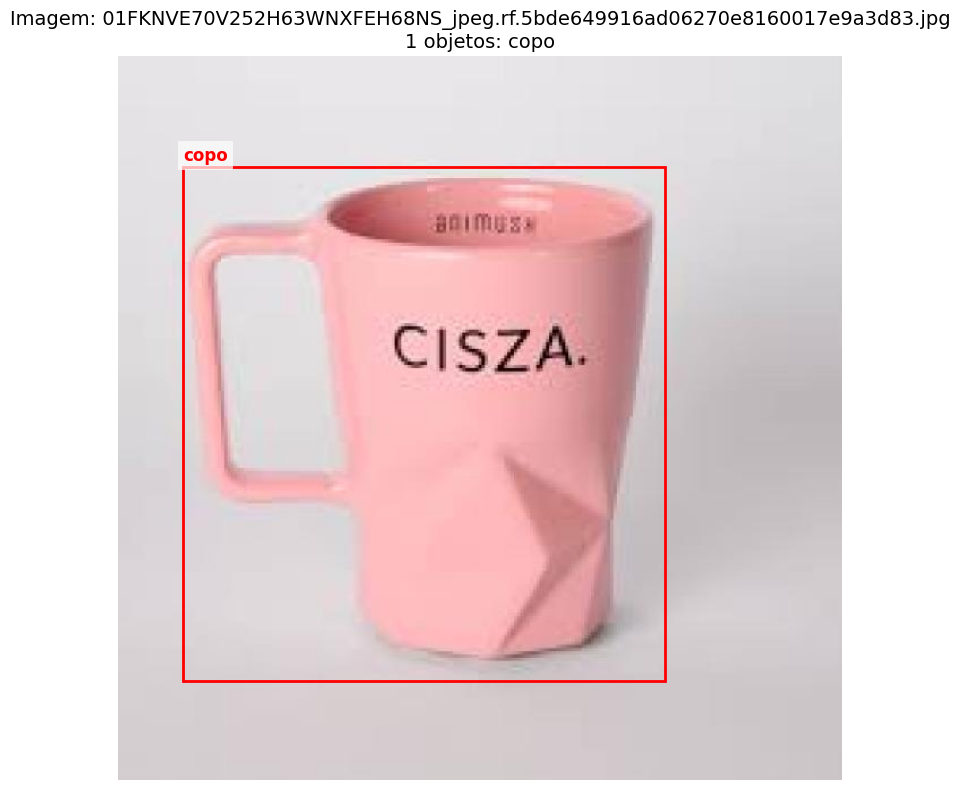

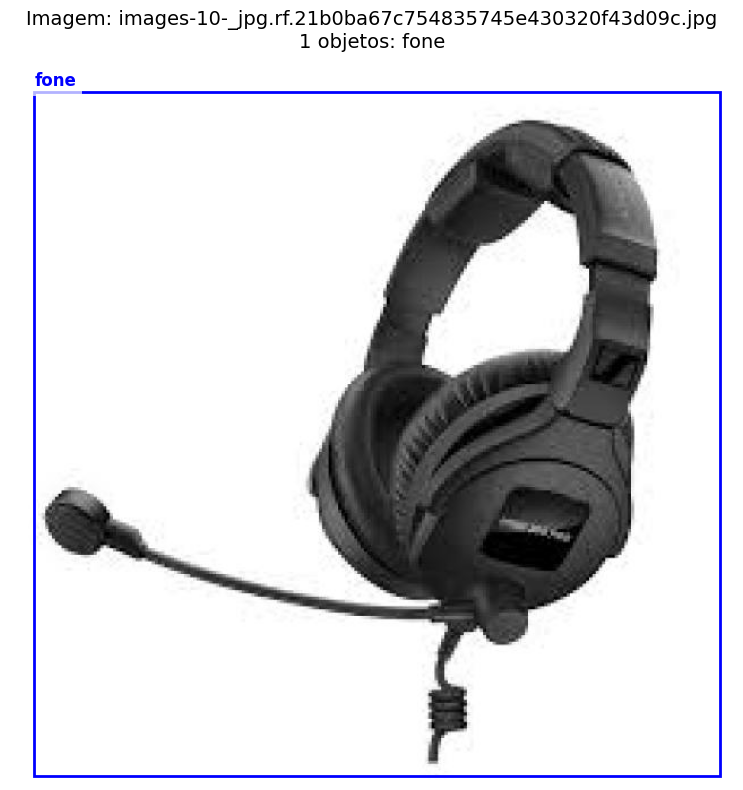

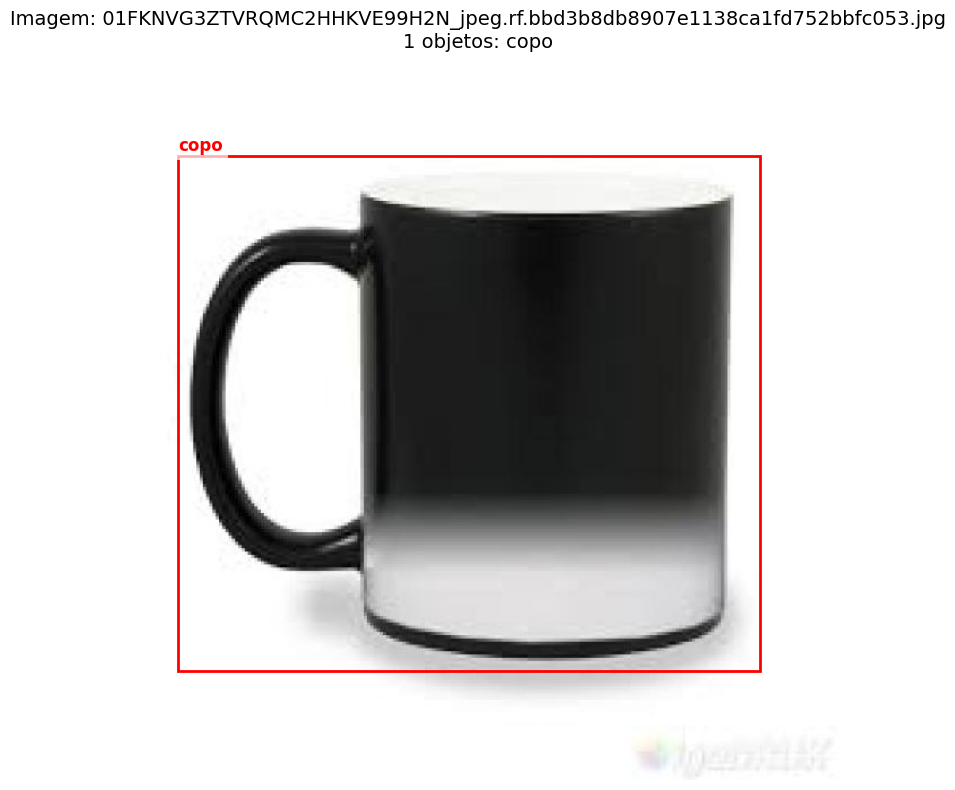

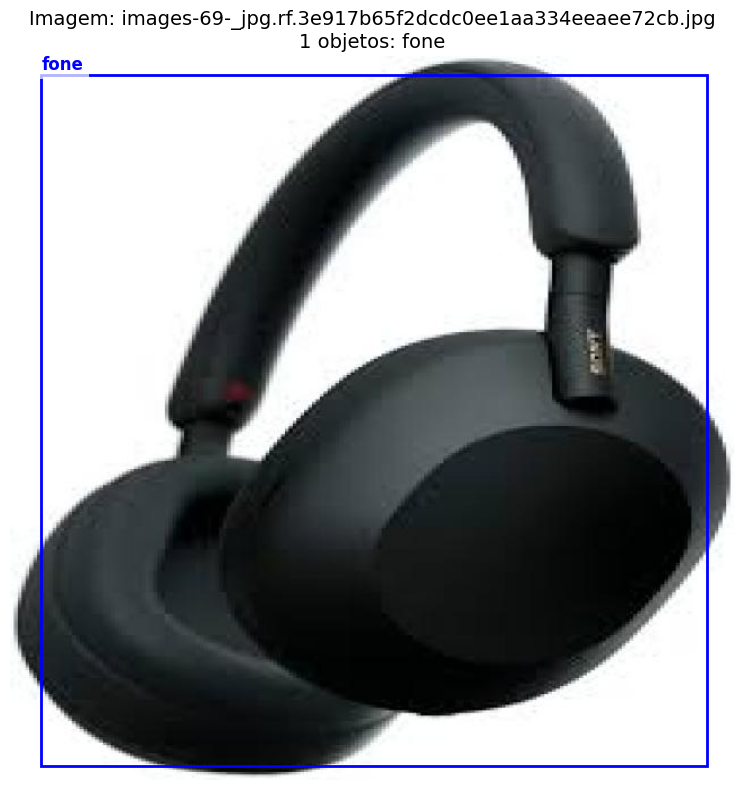

In [6]:
# Muda para o split de teste
split = 'test'  # Teste

# Parâmetros
base_dir = f'../dataset/{split}'
images_dir = os.path.join(base_dir, 'images')
labels_dir = os.path.join(base_dir, 'labels')

print(f"Visualizando amostras do split: {split}")
print(f"Diretório de imagens: {images_dir}")

# Verifica se os diretórios existem
if not os.path.exists(images_dir) or not os.path.exists(labels_dir):
    print(f"ERRO: Diretórios não encontrados para o split {split}")
else:
    # Conta o número de imagens disponíveis
    image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    print(f"Total de imagens disponíveis: {len(image_files)}")
    
    # Conta imagens por classe
    imagens_por_classe = {0: 0, 1: 0}
    imagens_multi_classe = 0
    
    for img_name in image_files:
        label_path = os.path.join(labels_dir, os.path.splitext(img_name)[0] + '.txt')
        if os.path.exists(label_path):
            classes_na_imagem = set()
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 1:
                        try:
                            cls_id = int(float(parts[0]))
                            classes_na_imagem.add(cls_id)
                        except:
                            pass
            
            if len(classes_na_imagem) > 1:
                imagens_multi_classe += 1
            elif len(classes_na_imagem) == 1:
                cls_id = list(classes_na_imagem)[0]
                if cls_id in imagens_por_classe:
                    imagens_por_classe[cls_id] += 1
    
    print(f"Imagens de {classes[0]}: {imagens_por_classe[0]}")
    print(f"Imagens de {classes[1]}: {imagens_por_classe[1]}")
    if imagens_multi_classe > 0:
        print(f"Imagens com múltiplas classes: {imagens_multi_classe}")
    
    # Seleciona imagens aleatórias
    amostras = random.sample(image_files, min(num_samples, len(image_files)))
    
    # Visualiza as amostras selecionadas
    for img_name in amostras:
        img_path = os.path.join(images_dir, img_name)
        label_path = os.path.join(labels_dir, os.path.splitext(img_name)[0] + '.txt')
        
        # Abre imagem
        img = Image.open(img_path)
        w, h = img.size
        
        # Lê labels
        boxes = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls_id, xc, yc, bw, bh = map(float, parts)
                        # Converte YOLO para coordenadas de canto
                        x1 = (xc - bw/2) * w
                        y1 = (yc - bh/2) * h
                        x2 = (xc + bw/2) * w
                        y2 = (yc + bh/2) * h
                        boxes.append((cls_id, x1, y1, x2-x1, y2-y1))
        
        # Plota
        fig, ax = plt.subplots(1, figsize=(10, 8))
        ax.imshow(img)
        
        # Adiciona bounding boxes e labels
        for cls_id, x, y, bw, bh in boxes:
            color = 'red' if int(cls_id) == 0 else 'blue'
            rect = patches.Rectangle((x, y), bw, bh, linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x, y-5, classes[int(cls_id)], color=color, fontsize=12, weight='bold', 
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        
        # Exibe nome do arquivo e informações
        num_boxes = len(boxes)
        box_info = f"{num_boxes} objetos: " + ", ".join([classes[int(b[0])] for b in boxes]) if boxes else "Sem objetos"
        ax.set_title(f'Imagem: {img_name}\n{box_info}', fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()